In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

   Transaction_ID  Transaction_Amount  Transaction_Time  Account_Age_Days  \
0             362               89.63                19              3058   
1              74              470.23                 3              3622   
2             375              387.88                22               879   
3             156              498.50                13              2630   
4             105              490.55                17               140   

   Transaction_Count_Day  Location_ID  Device_Type  Actual_Anomaly  \
0                      5            5            2               0   
1                      5            2            3               0   
2                      8            3            2               0   
3                      8            1            2               0   
4                      7            5            3               0   

   DBSCAN_Cluster  Predicted_Anomaly  
0               0                  0  
1               0                  1  

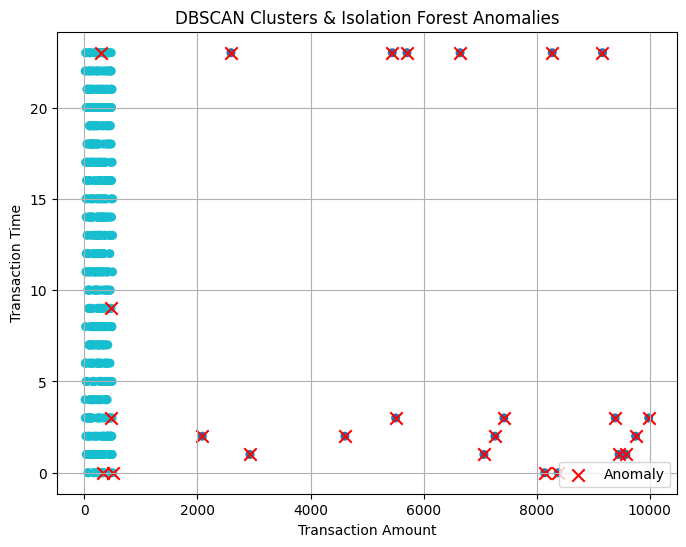

Results saved successfully!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab/isolation_forest_dataset.csv')

# Select features
X = df[["Transaction_Amount", "Transaction_Time", "Account_Age_Days"]]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.6, min_samples=8)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
predictions = iso.fit_predict(X_scaled)

# Convert predictions
df["Predicted_Anomaly"] = [1 if p == -1 else 0 for p in predictions]

# Display results
print(df.head())

print("\nCluster Counts:")
print(df["DBSCAN_Cluster"].value_counts())

print("\nDetected Anomalies:", df["Predicted_Anomaly"].sum())

# Visualization
plt.figure(figsize=(8,6))

# For visualization, let's use two of the selected features
plt.scatter(
    df["Transaction_Amount"],
    df["Transaction_Time"],
    c=df["DBSCAN_Cluster"],
    cmap="tab10",
    s=30
)

anomalies = df[df["Predicted_Anomaly"] == 1]

plt.scatter(
    anomalies["Transaction_Amount"],
    anomalies["Transaction_Time"],
    marker="x",
    s=80,
    color="red",
    label="Anomaly"
)

plt.title("DBSCAN Clusters & Isolation Forest Anomalies")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Time")
plt.legend()
plt.grid(True)
plt.show()

# Save results
df.to_csv("dbscan_isolation_results.csv", index=False)
print("Results saved successfully!")